In [115]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os


In [93]:
df = pd.read_csv('data.csv', encoding='iso-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [94]:
# Eksik CustomerID  
# RFM analizi müşteri bazlıdır, kimliği olmayan satırlar kullanılamaz 
print(f'Eksik CustomerID: {df["CustomerID"].isna().sum():,} ({df["CustomerID"].isna().mean()*100:.1f}%)')

df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print(f'Çıkarılan : {len(df) - len(df_clean):,} satır')
print(f'Kalan     : {len(df_clean):,} satır')


Eksik CustomerID: 135,080 (24.9%)
Çıkarılan : 135,080 satır
Kalan     : 406,829 satır


In [95]:
# Negatif ve sıfır Quantity
# Negatif değerler iade işlemlerini temsil eder
# Bunları ana analizden çıkarıp ayrı bir dosyada saklarız

mask_neg   = df_clean['Quantity'] <= 0 
df_returns = df_clean[mask_neg].copy()   
df_clean   = df_clean[~mask_neg].copy()

print(f'İade olarak ayrılan : {len(df_returns):,} satır')
print(f'Kalan : {len(df_clean):,} satır')

İade olarak ayrılan : 8,905 satır
Kalan : 397,924 satır


In [96]:
# Sıfır ve negatif UnitPrice
# Fiyatı olmayan ürünler promosyon veya veri hatası olabilir

mask_price = df_clean['UnitPrice'] <= 0
print(f'Çıkarılan : {mask_price.sum():,} satır')

df_clean = df_clean[~mask_price].copy()
print(f'Kalan : {len(df_clean):,} satır')

Çıkarılan : 40 satır
Kalan : 397,884 satır


In [97]:
# 'C' ile başlayan iptal faturaları
# InvoiceNo 'C' ile başlıyorsa o işlem iptal/iade faturasıdır

mask_cancel  = df_clean['InvoiceNo'].astype(str).str.startswith('C')
df_cancelled = df_clean[mask_cancel].copy()
df_clean     = df_clean[~mask_cancel].copy()

print(f'İptal faturası : {len(df_cancelled):,} satır')
print(f'Kalan          : {len(df_clean):,} satır')

İptal faturası : 0 satır
Kalan          : 397,884 satır


In [98]:
# Duplicate kayıtlar
# Aynı fatura + ürün + müşteri kombinasyonu birden fazla kez geçiyorsa
# yalnızca bir tanesi tutulur 
once = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'CustomerID'])

print(f'Çıkarılan : {once - len(df_clean):,} satır')
print(f'Kalan     : {len(df_clean):,} satır')

Çıkarılan : 10,043 satır
Kalan     : 387,841 satır


In [99]:
# Aykırı değerler (Winsorization)
# Toptan satıcıların çok büyük siparişleri aykırı değer yaratır
# Kırpmak yerine %99 eşiğiyle sınırlandırıyoruz (winsorization) 

q99_qty = df_clean['Quantity'].quantile(0.99)
q99_price = df_clean['UnitPrice'].quantile(0.99)

print(f'Quantity %99 eşiği : {q99_qty:.0f}')
print(f'UnitPrice %99 eşiği : {q99_price:.2f} £')

df_clean['Quantity'] = df_clean['Quantity'].clip(upper=q99_qty)
df_clean['UnitPrice'] = df_clean['UnitPrice'].clip(upper=q99_price)


Quantity %99 eşiği : 120
UnitPrice %99 eşiği : 14.95 £


In [100]:
# Dosyalara yaz
df_clean.to_csv('data_clean.csv', index=False)
df_returns.to_csv('data_returns.csv', index=False)

print('data_clean.csv kaydedildi')
print('data_returns.csv kaydedildi')

data_clean.csv kaydedildi
data_returns.csv kaydedildi


# RFM Hesaplama ve Skorlama 
RFM metriklerini hesaplar ve müşterileri segmentlere ayırır.

In [101]:
df = pd.read_csv('data_clean.csv')

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

REFERENCE_DATE = pd.Timestamp('2011-12-10')

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print(f'Temiz veri: {len(df):,} satır, {df["CustomerID"].nunique():,} müşteri')
df.head()

Temiz veri: 387,841 satır, 4,338 müşteri


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [102]:
# RFM METRİKLERİ
# Recency  : Referans tarihinden son alışverişe kadar geçen gün sayısı
# Frequency: Benzersiz fatura (sipariş) sayısı
# Monetary : Toplam harcama tutarı (£)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (REFERENCE_DATE - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print('RFM Tablosu:')
print(rfm.describe().round(2))
rfm.head(10)

RFM Tablosu:
       CustomerID  Recency  Frequency   Monetary
count     4338.00  4338.00    4338.00    4338.00
mean     15300.41    92.06       4.27    1753.86
std       1721.81   100.01       7.70    6314.87
min      12346.00     0.00       1.00       3.75
25%      13813.25    17.00       1.00     292.63
50%      15299.50    50.00       2.00     640.80
75%      16778.75   141.75       5.00    1567.39
max      18287.00   373.00     209.00  225194.65


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,124.80
1,12347,2,7,4185.20
2,12348,75,4,1328.43
3,12349,18,1,1443.50
4,12350,310,1,309.35
5,12352,36,8,1505.34
6,12353,204,1,89.00
7,12354,232,1,1073.40
8,12355,214,1,459.40
9,12356,22,3,2756.53


In [103]:
# RFM SKORLAMA (1-5 Quantile)
# Her metrik 5 eşit dilime ayrılır ve 1-5 arası skor alır
# Recency: düşük gün sayısı daha iyi → ters sıralama 
# Frequency ve Monetary: yüksek değer daha iyi → normal sıralama 

rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm['RFM_Segment'] = (rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str))

print('RFM Skorları:')
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Segment']].head(10)

RFM Skorları:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment
0,12346,325,1,124.80,1,1,1,3,111
1,12347,2,7,4185.20,5,5,5,15,555
2,12348,75,4,1328.43,2,4,4,10,244
3,12349,18,1,1443.50,4,1,4,9,414
4,12350,310,1,309.35,1,1,2,4,112
5,12352,36,8,1505.34,3,5,4,12,354
6,12353,204,1,89.00,1,1,1,3,111
7,12354,232,1,1073.40,1,1,4,6,114
8,12355,214,1,459.40,1,1,2,4,112
9,12356,22,3,2756.53,4,3,5,12,435


In [104]:
# MÜŞTERİ SEGMENTİ ETİKETLEME
# RFM skorlarına göre her müşteriye iş anlamı taşıyan bir etiket atanır

def rfm_segment(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    score   = row['RFM_Score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Şampiyonlar'        
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Sadık Müşteriler'   
    elif r >= 4 and f <= 2:
        return 'Yeni Müşteriler'    
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potansiyel Sadıklar' 
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Risk Altındakiler'  
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Kaybedilmek Üzere' 
    elif r <= 1 and f <= 2 and m <= 2:
        return 'Kayıp Müşteriler'   
    elif score >= 9:
        return 'Umut Vaad Edenler'
    else:
        return 'Pasif Müşteriler'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

# Segment özet tablosu
seg_summary = rfm.groupby('Segment').agg(
    Müşteri_Sayısı = ('CustomerID', 'count'),
    Ort_Recency    = ('Recency',    'mean'),
    Ort_Frequency  = ('Frequency',  'mean'),
    Ort_Monetary   = ('Monetary',   'mean'),
).round(1).sort_values('Müşteri_Sayısı', ascending=False)

print('Segment Dağılımı:')
print(seg_summary)

print('\nToplam gelirin segmentlere dağılımı:')
total = rfm['Monetary'].sum()
for seg_name, grp in rfm.groupby('Segment'):
    pct = grp['Monetary'].sum() / total * 100
    print(f'  {seg_name:<22}: %{pct:.1f}')

Segment Dağılımı:
                     Müşteri_Sayısı  Ort_Recency  Ort_Frequency  Ort_Monetary
Segment                                                                      
Pasif Müşteriler                987        126.9            1.4         421.0
Şampiyonlar                     952         12.2           11.1        5279.7
Sadık Müşteriler                769         35.0            4.1        1475.8
Kayıp Müşteriler                554        279.3            1.0         213.1
Risk Altındakiler               457        140.6            3.8        1369.7
Yeni Müşteriler                 312         17.8            1.2         401.1
Potansiyel Sadıklar             276         37.3            2.0         477.6
Umut Vaad Edenler                31         24.1            2.3         985.7

Toplam gelirin segmentlere dağılımı:
  Kayıp Müşteriler      : %1.6
  Pasif Müşteriler      : %5.5
  Potansiyel Sadıklar   : %1.7
  Risk Altındakiler     : %8.2
  Sadık Müşteriler      : %14.9
  Umut V

In [105]:
rfm.to_csv('rfm_segments.csv', index=False)
print('rfm_segments.csv kaydedildi')
rfm.head()

rfm_segments.csv kaydedildi


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Segment,Segment
0,12346,325,1,124.80,1,1,1,3,111,Kayıp Müşteriler
1,12347,2,7,4185.20,5,5,5,15,555,Şampiyonlar
2,12348,75,4,1328.43,2,4,4,10,244,Risk Altındakiler
3,12349,18,1,1443.50,4,1,4,9,414,Yeni Müşteriler
4,12350,310,1,309.35,1,1,2,4,112,Kayıp Müşteriler


# K-Means Kümeleme
`rfm_segments.csv` üzerinde Elbow + Silhouette ile optimal k bulunur, ardından k=3 ile kümeleme yapılır.

In [106]:
rfm = pd.read_csv('rfm_segments.csv')
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.family'      : 'DejaVu Serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 150,
})

# Log dönüşümü + StandardScaler
X = rfm[['Recency','Frequency','Monetary']].copy()
X = X.dropna()
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary']  = np.log1p(X['Monetary'])

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Veri hazır: {X_scaled.shape[0]:,} müşteri, 3 özellik')


Veri hazır: 4,338 müşteri, 3 özellik


k=2  |  Inertia:     6827.2  |  Silhouette: 0.4077
k=3  |  Inertia:     4253.1  |  Silhouette: 0.4165
k=4  |  Inertia:     3195.3  |  Silhouette: 0.3835
k=5  |  Inertia:     2708.9  |  Silhouette: 0.3455
k=6  |  Inertia:     2346.5  |  Silhouette: 0.3339
k=7  |  Inertia:     2115.7  |  Silhouette: 0.3034
k=8  |  Inertia:     1915.1  |  Silhouette: 0.3015
k=9  |  Inertia:     1770.7  |  Silhouette: 0.2848
k=10  |  Inertia:     1640.4  |  Silhouette: 0.2846


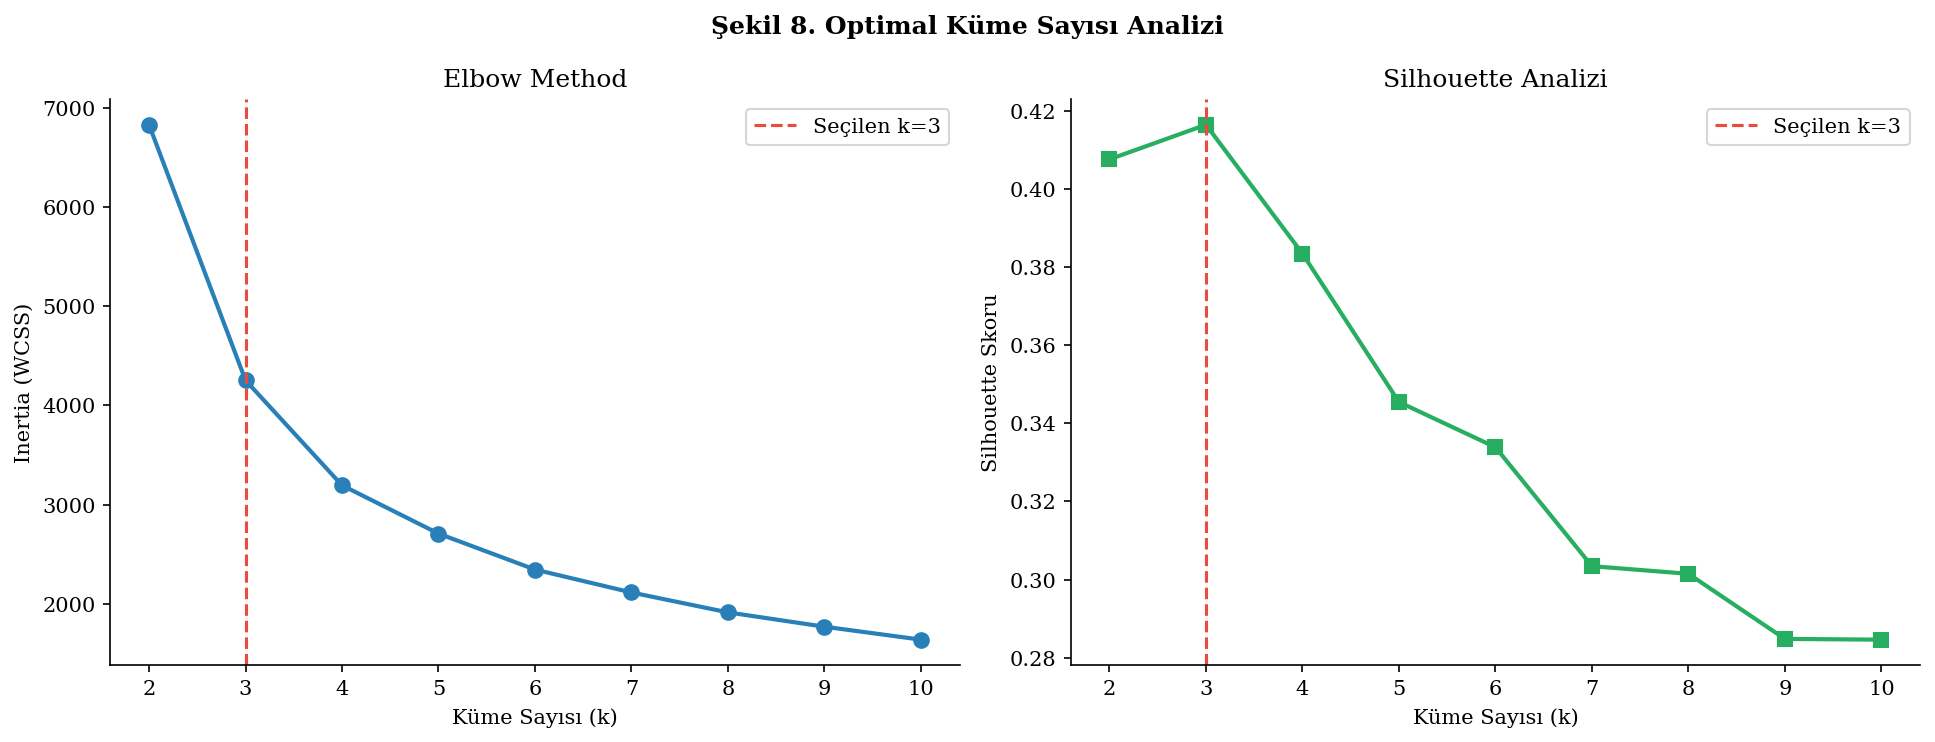

In [111]:
#  ELBOW + SİLHOUETTE 

inertias    = [] 
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))
    print(f'k={k}  |  Inertia: {km.inertia_:>10.1f}  |  Silhouette: {silhouette_score(X_scaled, km.labels_):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Şekil 8. Optimal Küme Sayısı Analizi', fontweight='bold')

axes[0].plot(K_range, inertias, 'o-', color='#2980b9', linewidth=2, markersize=7)
axes[0].set_xlabel('Küme Sayısı (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=1.5, label='Seçilen k=3')
axes[0].legend()

axes[1].plot(K_range, silhouettes, 's-', color='#27ae60', linewidth=2, markersize=7)
axes[1].set_xlabel('Küme Sayısı (k)')
axes[1].set_ylabel('Silhouette Skoru')
axes[1].set_title('Silhouette Analizi')
axes[1].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=1.5, label='Seçilen k=3')
axes[1].legend()

plt.tight_layout()
plt.show()

In [112]:
# K-MEANS k=3 

km = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = km.fit_predict(X_scaled)

cluster_summary = rfm.groupby('Cluster').agg(
    Müşteri_Sayısı = ('CustomerID', 'count'),
    Ort_Recency    = ('Recency', 'mean'),
    Ort_Frequency  = ('Frequency', 'mean'),
    Ort_Monetary   = ('Monetary', 'mean'),
    Top_Monetary   = ('Monetary', 'sum'),
).round(1)

print('Küme Özeti:')
print(cluster_summary)

label_map = {}
for c in [0, 1, 2]:
    r = cluster_summary.loc[c, 'Ort_Recency']
    m = cluster_summary.loc[c, 'Ort_Monetary']
    if r == cluster_summary['Ort_Recency'].min() and m == cluster_summary['Ort_Monetary'].max():
        label_map[c] = 'Platin Müşteri'
    elif r == cluster_summary['Ort_Recency'].max():
        label_map[c] = 'Gümüş Müşteri'
    else:
        label_map[c] = 'Altın Müşteri'

rfm['Cluster_Label'] = rfm['Cluster'].map(label_map)

total = rfm['Monetary'].sum()
print('\nGelir payları:')
for label, grp in rfm.groupby('Cluster_Label'):
    print(f'  {label:<18}: {grp["CustomerID"].count():>5} müşteri  |  %{grp["Monetary"].sum()/total*100:.1f} gelir')

Küme Özeti:
         Müşteri_Sayısı  Ort_Recency  Ort_Frequency  Ort_Monetary  \
Cluster                                                             
0                  2022         54.4            2.0         577.7   
1                  1335         29.6            9.8        4554.6   
2                   981        254.6            1.4         366.7   

         Top_Monetary  
Cluster                
0           1168151.7  
1           6080340.7  
2            359765.2  

Gelir payları:
  Altın Müşteri     :  2022 müşteri  |  %15.4 gelir
  Gümüş Müşteri     :   981 müşteri  |  %4.7 gelir
  Platin Müşteri    :  1335 müşteri  |  %79.9 gelir


 # Cohort Analizi
 `data_clean.csv` üzerinden aylık cohort grupları oluşturulur ve müşteri elde tutma oranları görselleştirilir.

In [113]:
df = pd.read_csv('data_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.family'      : 'DejaVu Serif',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 150,
})

print(f'Veri yüklendi: {len(df):,} satır')

Veri yüklendi: 387,841 satır


In [114]:
# COHORT HESAPLAMA 
# CohortMonth : Her müşterinin ilk alışveriş yaptığı ay
# OrderMonth  : İşlemin gerçekleştiği ay
# CohortIndex : İlk alışverişten kaç ay sonra? (0 = ilk ay)

df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

df['OrderMonth']  = df['InvoiceDate'].dt.to_period('M')

df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

cohort_data = df.groupby(['CohortMonth','CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_data.columns = ['CohortMonth','CohortIndex','Customers']

# Pivot tablo 
cohort_pivot = cohort_data.pivot(
    index='CohortMonth', columns='CohortIndex', values='Customers'
)

# Elde tutma oranı (her satırı index=0'a böl)
retention = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3)

print('Cohort Pivot (ilk 5 cohort, ilk 6 ay):')
print(cohort_pivot.iloc[:5, :6])
print('\nElde Tutma Oranı (%):')
print((retention.iloc[:5, :6] * 100).round(1))

Cohort Pivot (ilk 5 cohort, ilk 6 ay):
CohortIndex      0      1      2      3      4      5
CohortMonth                                          
2010-12      885.0  324.0  286.0  340.0  321.0  352.0
2011-01      417.0   92.0  111.0   96.0  134.0  120.0
2011-02      380.0   71.0   71.0  108.0  103.0   94.0
2011-03      452.0   68.0  114.0   90.0  101.0   76.0
2011-04      300.0   64.0   61.0   63.0   59.0   68.0

Elde Tutma Oranı (%):
CohortIndex      0     1     2     3     4     5
CohortMonth                                     
2010-12      100.0  36.6  32.3  38.4  36.3  39.8
2011-01      100.0  22.1  26.6  23.0  32.1  28.8
2011-02      100.0  18.7  18.7  28.4  27.1  24.7
2011-03      100.0  15.0  25.2  19.9  22.3  16.8
2011-04      100.0  21.3  20.3  21.0  19.7  22.7


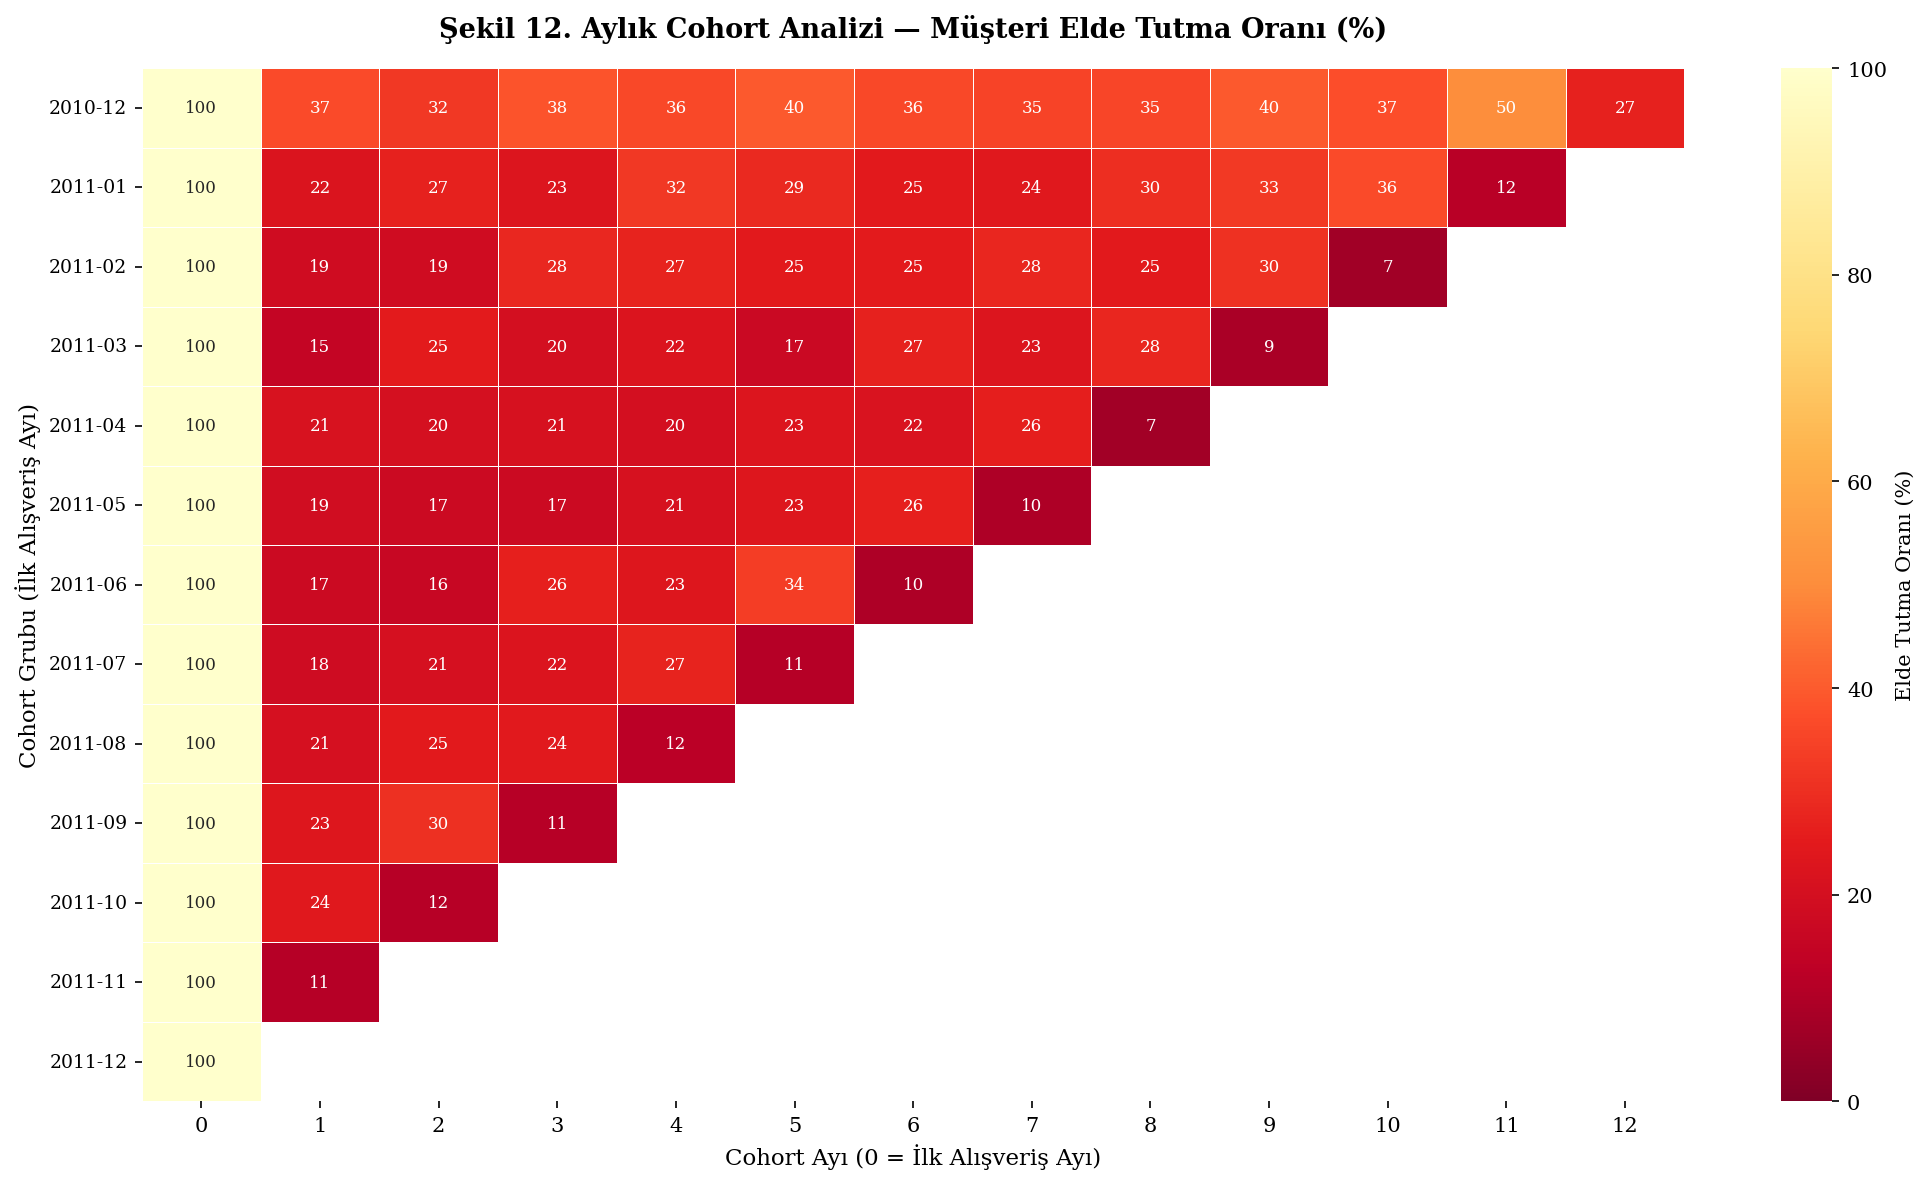

In [116]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    retention * 100,
    annot=True, fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Elde Tutma Oranı (%)'},
    vmin=0, vmax=100,
    annot_kws={'size': 8}
)

ax.set_title('Şekil 12. Aylık Cohort Analizi — Müşteri Elde Tutma Oranı (%)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Cohort Ayı (0 = İlk Alışveriş Ayı)', fontsize=11)
ax.set_ylabel('Cohort Grubu (İlk Alışveriş Ayı)', fontsize=11)
ax.set_yticklabels([str(p) for p in retention.index], rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

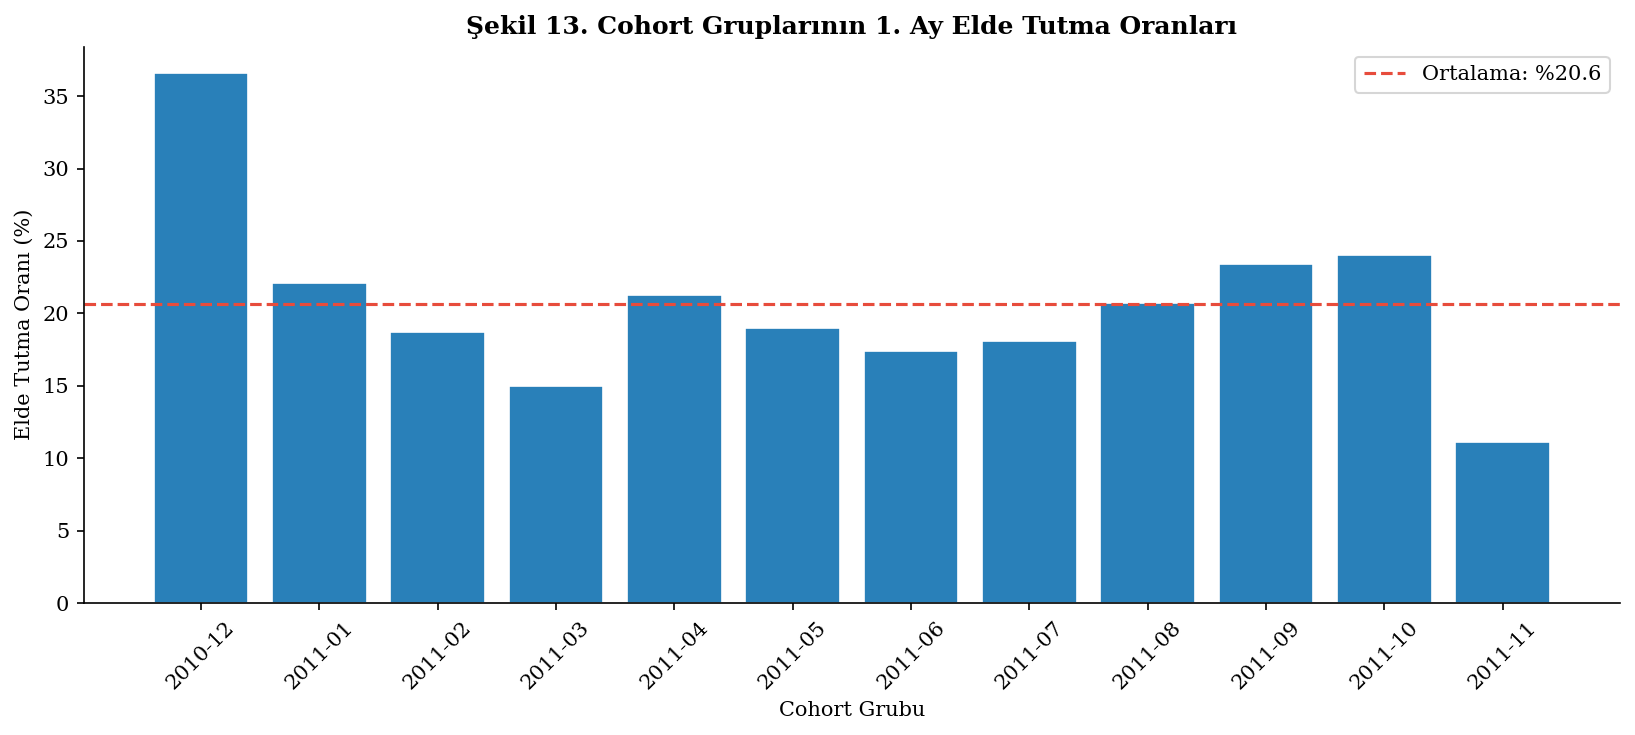

Ortalama 1. ay tutma : %20.6
En yüksek            : %36.6  (2010-12)
En düşük             : %11.1  (2011-11)
cohort_retention.csv kaydedildi


In [117]:
month1_retention = retention[1].dropna() * 100

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(
    month1_retention.index.astype(str),
    month1_retention.values,
    color='#2980b9', edgecolor='white', linewidth=0.8
)
ax.axhline(
    month1_retention.mean(), color='#e74c3c', linestyle='--',
    linewidth=1.5, label=f'Ortalama: %{month1_retention.mean():.1f}'
)
ax.set_xlabel('Cohort Grubu')
ax.set_ylabel('Elde Tutma Oranı (%)')
ax.set_title('Şekil 13. Cohort Gruplarının 1. Ay Elde Tutma Oranları', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('figures/fig13_cohort_month1.png', bbox_inches='tight')
plt.show()

# Özet
print(f'Ortalama 1. ay tutma : %{month1_retention.mean():.1f}')
print(f'En yüksek            : %{month1_retention.max():.1f}  ({month1_retention.idxmax()})')
print(f'En düşük             : %{month1_retention.min():.1f}  ({month1_retention.idxmin()})')

retention.to_csv('cohort_retention.csv')
print('cohort_retention.csv kaydedildi')